In [2]:
import pandas as pd 

df =pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [5]:
from sklearn.model_selection import train_test_split as tts 
from sklearn.linear_model import LogisticRegression 

X_train,X_test,y_train,y_test = tts(X,y,test_size=0.2, random_state=42)

In [7]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]


In [12]:
y_prob[:5]

array([0.27587171, 0.18844086, 0.11448808, 0.16354446, 0.47152763])

In [13]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

fpr,tpr, threshold = roc_curve(y_test,y_prob)

In [14]:
threshold

array([       inf, 0.97115521, 0.96813003, 0.95629563, 0.90262249,
       0.89734144, 0.80096521, 0.7781665 , 0.77789864, 0.77733211,
       0.7328617 , 0.72427692, 0.68328935, 0.67523613, 0.66096112,
       0.66077894, 0.6555798 , 0.64967188, 0.6393479 , 0.61668745,
       0.60581059, 0.58366935, 0.55036457, 0.5394989 , 0.53417122,
       0.50297386, 0.50239275, 0.42044193, 0.42015964, 0.40861817,
       0.38092464, 0.33903877, 0.32718599, 0.30303447, 0.30268011,
       0.25731429, 0.24066279, 0.22533799, 0.2251495 , 0.20841338,
       0.20492144, 0.16354446, 0.14043101, 0.12822715, 0.12698331,
       0.11448808, 0.11430304, 0.04152087, 0.04047859, 0.00417295])

In [15]:
import plotly.graph_objects as go 
import numpy as np

In [16]:
import matplotlib.pyplot as plt 

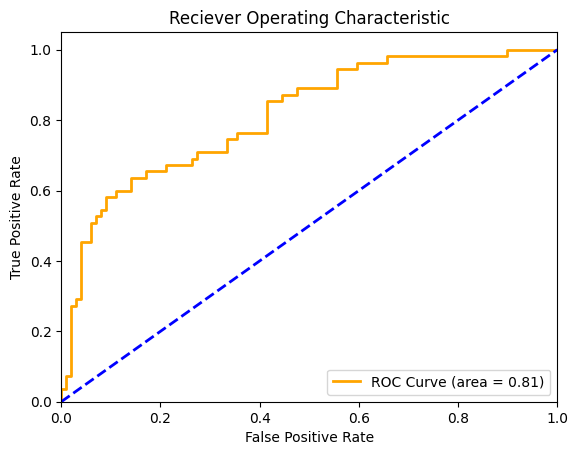

In [17]:
plt.figure()
plt.plot(fpr,tpr, color='orange', lw=2,label= 'ROC Curve (area = %0.2f)' % roc_auc_score(y_test,y_prob))
plt.plot([0,1],[0,1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.title("Reciever Operating Characteristic")
plt.show()

In [22]:
# AUC-ROC

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
import numpy as np 
clf1 = LogisticRegression()
clf2 = SVC(probability=True)


In [23]:
scalar = StandardScaler()

In [24]:
X_train,X_test = scalar.fit_transform(X_train), scalar.transform(X_test)

clf1.fit(X_train,y_train)
clf1_prob = clf1.predict_proba(X_test)[:,1]

clf2.fit(X_train,y_train)
clf2_prob = clf2.predict_proba(X_test)[:,1]


In [26]:
fpr1,tpr1,tr1 = roc_curve(y_test,clf1_prob)
auc1 = roc_auc_score(y_test,clf1_prob)
fpr2,tpr2,tr2 = roc_curve(y_test,clf2_prob)
auc2 = roc_auc_score(y_test,clf2_prob)
